In [1]:
from pyomo.environ import *
import numpy as np
import matplotlib.pyplot as plt
import time


In [2]:
#parameters
total_area_for_planting = 500
farmer_quota = 6000
planting_cost_per_acre = [ 150, 230, 260]

scenario_prob = {1:1/3, 2:1/3 , 3:1/3}
Crop_harvest_coefficients = {1:[2.5 , 3 , 20], 2:[3, 3.6, 24], 3:[2, 2.4, 16]}
least_need = {1: [200 ,240],2: [200 ,240],3: [200 ,240]}
selling_price ={1:[-170, -150, -36, -10],2:[-170, -150, -36, -10],3:[-170, -150, -36, -10]}
purchase_price = {1: [ 238, 210],2: [ 238, 210],3: [ 238, 210]}

In [3]:
# parametrs_with_uncertainty
def tast_data_book_farmer_problem():
    """ داده های کتاب برای سه سناریو که به جواب زیر باید برسد
                 x[1]=170 , x[2]=80 x[3]=250
    برای ریز جزییات به کتاب مرجع فصل اول مراجعه کنید
    """
    global least_need,Crop_harvest_coefficients,purchase_price,selling_price,scenario_prob
    scenario = 3
    scenario_prob = {1:1/3, 2:1/3 , 3:1/3}
    Crop_harvest_coefficients = {1:[2.5 , 3 , 20], 2:[3, 3.6, 24], 3:[2, 2.4, 16]}
    least_need = {1: [200 ,240],2: [200 ,240],3: [200 ,240]}
    selling_price ={1:[-170, -150, -36, -10],2:[-170, -150, -36, -10],3:[-170, -150, -36, -10]}
    purchase_price = {1: [ 238, 210],2: [ 238, 210],3: [ 238, 210]}
    return  least_need,Crop_harvest_coefficients,purchase_price,selling_price,scenario_prob,scenario

#generate data 
def tast_data_50(num_bins = 8):
    global least_need,Crop_harvest_coefficients,purchase_price,selling_price,scenario,scenario_prob
    scenario_prob = {}
    Crop_harvest_coefficients = {}
    least_need = {}
    selling_price ={}
    purchase_price = {}

    Crop_harvest_coefficients_initial = [2.5 , 3.0 , 20.0]
    selling_price_initial = [-170, -150, -36, -10]
    purchase_price_initial= [ 238, 210]

    num_samples = 20000
    #num_bins = 8
    lower_bound = -1.0
    upper_bound = 1.0
    mu = 0
    sigma = 0.33
    scenario = num_bins*num_bins

    # making omega and error term
    samples_x = np.random.normal(mu, sigma, num_samples)
    samples_y = np.random.normal(mu, sigma, num_samples)

    mask = (samples_x >= lower_bound) & (samples_x <= upper_bound) & \
        (samples_y >= lower_bound) & (samples_y <= upper_bound)
    samples_x = samples_x[mask]
    samples_y = samples_y[mask]

    while len(samples_x) < num_samples:
        new_x = np.random.normal(mu, sigma, num_samples - len(samples_x))
        new_y = np.random.normal(mu, sigma, num_samples - len(samples_x))
        mask = (new_x >= lower_bound) & (new_x <= upper_bound) & \
            (new_y >= lower_bound) & (new_y <= upper_bound)
        samples_x = np.concatenate([samples_x, new_x[mask]])
        samples_y = np.concatenate([samples_y, new_y[mask]])

    samples_x = samples_x[:num_samples]
    samples_y = samples_y[:num_samples]

    bin_edges = np.linspace(lower_bound, upper_bound, num_bins + 1)

    scenarios = []
    total_samples = len(samples_x)

    for i in range(num_bins):
        for j in range(num_bins):
            if i == num_bins - 1 and j == num_bins - 1:
                mask = (samples_x >= bin_edges[i]) & (samples_x <= bin_edges[i+1]) & \
                    (samples_y >= bin_edges[j]) & (samples_y <= bin_edges[j+1])
            elif i == num_bins - 1:
                mask = (samples_x >= bin_edges[i]) & (samples_x <= bin_edges[i+1]) & \
                    (samples_y >= bin_edges[j]) & (samples_y < bin_edges[j+1])
            elif j == num_bins - 1:
                mask = (samples_x >= bin_edges[i]) & (samples_x < bin_edges[i+1]) & \
                    (samples_y >= bin_edges[j]) & (samples_y <= bin_edges[j+1])
            else:
                mask = (samples_x >= bin_edges[i]) & (samples_x < bin_edges[i+1]) & \
                    (samples_y >= bin_edges[j]) & (samples_y < bin_edges[j+1])
            
            points_x = samples_x[mask]
            points_y = samples_y[mask]
            count = len(points_x)
            
            if count == 0:
                mean_x = (bin_edges[i] + bin_edges[i+1]) / 2
                mean_y = (bin_edges[j] + bin_edges[j+1]) / 2
                probability = 0
            else:
                mean_x = np.mean(points_x)
                mean_y = np.mean(points_y)
                probability = count / total_samples
            
            scenarios.append({
                'x_bin': (bin_edges[i], bin_edges[i+1]),
                'y_bin': (bin_edges[j], bin_edges[j+1]),
                'count': count,
                'probability': probability,
                'mean_x': mean_x,
                'mean_y': mean_y
            })

    print(f"تعداد کل نمونه‌های معتبر: {total_samples}")
    print("=" * 100)
    print(f"{'بازه X':<16} {'بازه Y':<16} {'تعداد':<8} {'احتمال':<12} {'میانگین X':<12} {'میانگین Y':<12}")
    print("-" * 100)

    total_prob = 0
    for s in scenarios:
        print(f"[{s['x_bin'][0]:>5.2f}, {s['x_bin'][1]:>5.2f}]  [{s['y_bin'][0]:>5.2f}, {s['y_bin'][1]:>5.2f}]  {s['count']:<8} {s['probability']:<12.4f} {s['mean_x']:<12.4f} {s['mean_y']:<12.4f}")
        total_prob += s['probability']

    print("-" * 100)
    print(f"مجموع احتمالات: {total_prob:.4f}")
    

    x_values = [s['mean_x'] for s in scenarios]
    y_values = [s['mean_y'] for s in scenarios]
    p_values = [s['probability'] for s in scenarios]
   

    print("\n" + "=" * 100)
    print("خروجی نهایی برای ال‌شکل:")
    print("=" * 100)
    print(f"تعداد سناریوها: {len(scenarios)}")
    print(f"\nx = [{', '.join([f'{x:.4f}' for x in x_values])}]")
    print(f"\ny = [{', '.join([f'{y:.4f}' for y in y_values])}]")
    print(f"\np = [{', '.join([f'{p:.4f}' for p in p_values])}]")


    

    omega_error = zip([f'{x:.4f}' for x in x_values],[f'{y:.4f}' for y in y_values],[f'{p:.4f}' for p in p_values])
    omega_error = [i for i in omega_error]
    print(f"ccccccccccccccccccccccccccccccccccccccccccccccccccccccccc{len(omega_error)}")
    print(omega_error)
    for enu , s in enumerate(omega_error):
        scenario_prob[enu+1] = float(omega_error[enu][2])
        white_harvest_coefficients = Crop_harvest_coefficients_initial[0]+Crop_harvest_coefficients_initial[0]*float(omega_error[enu][0])
        crop_harvest_coefficients = Crop_harvest_coefficients_initial[1]+Crop_harvest_coefficients_initial[1]*float(omega_error[enu][0])
        bite_harvest_coefficients = Crop_harvest_coefficients_initial[2]+Crop_harvest_coefficients_initial[2]*float(omega_error[enu][0])
        selling_price_initial =[i-0.1*i*float(omega_error[enu][0])+0.1*i*float(omega_error[enu][1]) for i in selling_price_initial]
        purchase_price_initial = [i-0.1*i*float(omega_error[enu][0])+0.1*i*float(omega_error[enu][1]) for i in purchase_price_initial]
        Crop_harvest_coefficients[enu+1] = [white_harvest_coefficients,crop_harvest_coefficients,bite_harvest_coefficients]
        selling_price[enu+1]=selling_price_initial
        purchase_price[enu+1]= purchase_price_initial 
        least_need[enu+1] = [200,240] 
        
        
    return least_need,Crop_harvest_coefficients,purchase_price,selling_price,scenario,scenario_prob




In [4]:
tast_data_50()
print("scenario_prob",scenario_prob,"least_need",least_need,"Crop_harvest_coefficients:",Crop_harvest_coefficients,"purchase_price",purchase_price,"selling_price",selling_price)



تعداد کل نمونه‌های معتبر: 20000
بازه X           بازه Y           تعداد    احتمال       میانگین X    میانگین Y   
----------------------------------------------------------------------------------------------------
[-1.00, -0.75]  [-1.00, -0.75]  5        0.0003       -0.7911      -0.8764     
[-1.00, -0.75]  [-0.75, -0.50]  11       0.0006       -0.8191      -0.6038     
[-1.00, -0.75]  [-0.50, -0.25]  39       0.0019       -0.8368      -0.3610     
[-1.00, -0.75]  [-0.25,  0.00]  70       0.0035       -0.8258      -0.1282     
[-1.00, -0.75]  [ 0.00,  0.25]  49       0.0024       -0.8298      0.1118      
[-1.00, -0.75]  [ 0.25,  0.50]  43       0.0022       -0.8397      0.3685      
[-1.00, -0.75]  [ 0.50,  0.75]  14       0.0007       -0.8541      0.6117      
[-1.00, -0.75]  [ 0.75,  1.00]  3        0.0001       -0.8110      0.9049      
[-0.75, -0.50]  [-1.00, -0.75]  10       0.0005       -0.5508      -0.8195     
[-0.75, -0.50]  [-0.75, -0.50]  51       0.0026       -0.6040    

In [5]:
#از محاسبه اضافه و ساخت مدل برای استخراج جلوگیری کرده ایم
# محاسبه ضرایب اچ و تی. لزومی ندارد حتما مدل را بسازیم و ضرایب را مستقیما استخراج کنیم. چون ساختار مدل یکسان است میتوان از تابع زیر استفاده کردو قبل حل بندرز از ان
h = {}
for s in range(1,scenario+1):
    h[s] = [least_need[s][0],least_need[s][1],0,-1*farmer_quota]
h

t = {}
for s in range(1,scenario+1):
    scenario_t = np.array([[Crop_harvest_coefficients[s][0],0,0],
                       [0,Crop_harvest_coefficients[s][1],0],
                       [0,0,Crop_harvest_coefficients[s][2]],
                       [0,0,0]])
    t[s] = scenario_t

print(f"t:{t},h:{h}")

t:{1: array([[0.52225, 0.     , 0.     ],
       [0.     , 0.6267 , 0.     ],
       [0.     , 0.     , 4.178  ],
       [0.     , 0.     , 0.     ]]), 2: array([[0.45225, 0.     , 0.     ],
       [0.     , 0.5427 , 0.     ],
       [0.     , 0.     , 3.618  ],
       [0.     , 0.     , 0.     ]]), 3: array([[0.408 , 0.    , 0.    ],
       [0.    , 0.4896, 0.    ],
       [0.    , 0.    , 3.264 ],
       [0.    , 0.    , 0.    ]]), 4: array([[0.4355, 0.    , 0.    ],
       [0.    , 0.5226, 0.    ],
       [0.    , 0.    , 3.484 ],
       [0.    , 0.    , 0.    ]]), 5: array([[0.4255, 0.    , 0.    ],
       [0.    , 0.5106, 0.    ],
       [0.    , 0.    , 3.404 ],
       [0.    , 0.    , 0.    ]]), 6: array([[0.40075, 0.     , 0.     ],
       [0.     , 0.4809 , 0.     ],
       [0.     , 0.     , 3.206  ],
       [0.     , 0.     , 0.     ]]), 7: array([[0.36475, 0.     , 0.     ],
       [0.     , 0.4377 , 0.     ],
       [0.     , 0.     , 2.918  ],
       [0.     , 0.     , 0.

In [6]:
# whole algorythm
t0 = time.time()

nofc, nooc, v = (0, 0, 0)
theta_values = {} 
w = {}

for s in range(1,scenario+1):
    w[s]=[]

#master intilization
master = ConcreteModel()
master.i = RangeSet(3)
master.x = Var(master.i , domain=NonNegativeReals)
master.scenario = RangeSet(scenario)
master.theta = Var(master.scenario , domain=Reals)

master.obj = Objective(expr =sum( planting_cost_per_acre[i-1]*master.x[i] for i in master.i) 
                       + sum(master.theta[s] for s in master.scenario))

def rule_c1(master):
    return sum(master.x[i] for i in master.i) <= total_area_for_planting
master.c1 = Constraint( rule= rule_c1)
master.optimality_cut = ConstraintList()
master.feasibility_cut = ConstraintList()
master.theta_initialization = ConstraintList()

not_stop_condition = True
counter_while = 1
while not_stop_condition:
    counter_while+=1
    if counter_while>=50:
        print(f"**************************************")
        for enum, s in enumerate(master.scenario):
            print(f"theta_values = {theta_values[s][-1]},w={w[s][-1]}")
        print(f"theta_values = {theta_values},w={w}")
        break
    v += 1
    if v == 1:
        master.theta_initialization = ConstraintList()
        for enum, s in enumerate(master.scenario):
            master.theta_initialization.add (master.theta[s] == -100000 )
            theta_values[s]=[-100000]
    else:
        master.theta_initialization.deactivate()
        for enum, s in enumerate(master.scenario):
            print(f"\n[Theta{master.theta[s]} from previous iteration: {value(master.theta[s]):,.2f}]")
            theta_values[s].append(value(master.theta[s]))

    solver=SolverFactory('cplex')
    result=solver.solve(master, tee=False)
    if result.solver.termination_condition == TerminationCondition.infeasible:
        print(f"**************************************")
        print(f"model is infisible")
        break

    print("\n" + "="*50)
    print(f"🔁 Iteration {v}")
    print("-"*50)
    print(f" Master Problem Objective Value : {value(master.obj):,.2f}")
    print(f" Decision Variables:")
    for i in master.i:
        print(f'{master.x[i]}: {value(master.x[i])}')
    print("="*50)
    
    print("---------------------feasibility check-------------------------")
    for s in range(1,scenario+1):
        print("\n" + "-"*50)
        print(f" scenario{s}")
        print("-"*50)
        


        # feasibility check
        
        feasibility_simplex_multiplier ={}
        dual_feasibility_subproblem=[]

        feasibility_sub = ConcreteModel()
        feasibility_sub.consentraint_index = RangeSet(4)
        feasibility_sub.sale_index = RangeSet(4)
        feasibility_sub.purchase_index = RangeSet(2)

        feasibility_sub.positiveV = Var(feasibility_sub.consentraint_index, domain = NonNegativeReals)
        feasibility_sub.negetiveV = Var(feasibility_sub.consentraint_index, domain = NonNegativeReals)
        feasibility_sub.w = Var(feasibility_sub.sale_index, domain = NonNegativeReals)
        feasibility_sub.y = Var(feasibility_sub.purchase_index, domain = NonNegativeReals)

        rule_obj = sum(feasibility_sub.positiveV[i] for i in feasibility_sub.consentraint_index)+sum(feasibility_sub.negetiveV[i] for i in feasibility_sub.consentraint_index)
        feasibility_sub.obj = Objective(expr=rule_obj )
            

        feasibility_sub.c1 = Constraint(expr = feasibility_sub.y[1]+ (-1)*feasibility_sub.w[1]+feasibility_sub.positiveV[1]-feasibility_sub.negetiveV [1]>= least_need[s][0] - Crop_harvest_coefficients[s][0]* value(master.x[1]))
        feasibility_sub.c2 = Constraint(expr = feasibility_sub.y[2]+ (-1)*feasibility_sub.w[2]+feasibility_sub.positiveV[2]-feasibility_sub.negetiveV [2]>= least_need[s][1] - Crop_harvest_coefficients[s][1]* value(master.x[2]))
        feasibility_sub.c3 = Constraint(expr = -feasibility_sub.w[3]-feasibility_sub.w[4]+feasibility_sub.positiveV[3]-feasibility_sub.negetiveV [3]>= -Crop_harvest_coefficients[s][2]*value(master.x[3]))
        feasibility_sub.c4 = Constraint(expr = -feasibility_sub.w[3]+feasibility_sub.positiveV[4]-feasibility_sub.negetiveV [4] >= -farmer_quota)
        

        feasibility_sub.dual = Suffix(direction=Suffix.IMPORT)
        solver = SolverFactory('cplex')
        result = solver.solve(feasibility_sub)


        #dual feasibility
        for c in feasibility_sub.component_objects( Constraint, active = True ):
            cobject = getattr( feasibility_sub, str( c ) )
            for index in cobject:
                dual_feasibility_subproblem.append(feasibility_sub.dual[cobject[index]])
            
        feasibility_simplex_multiplier[s] = dual_feasibility_subproblem

        print(f"\n🔹 Scenario {s} feasibility check:")
        print(f"    π (Dual values) = {feasibility_simplex_multiplier[s]}")

        # disply answer 
        positive_negetive_v_list = []
        #print(value(feasibility_sub.obj))
        #for i in feasibility_sub.sale_index:
        #    print(f"{feasibility_sub.w[i]}:{value(feasibility_sub.w[i])}")
        #for i in feasibility_sub.purchase_index:
        #    print(f"{feasibility_sub.y[i]}:{value(feasibility_sub.y[i])}")
        for i in feasibility_sub.consentraint_index:
            positive_negetive_v_list.append(value(feasibility_sub.positiveV[i]))
            positive_negetive_v_list.append(value(feasibility_sub.negetiveV[i]))                              
        #    print(f"{feasibility_sub.positiveV[i]}:{value(feasibility_sub.positiveV[i])}")
        #    print(f"{feasibility_sub.negetiveV[i]}:{value(feasibility_sub.negetiveV[i])}")
        positive_negetive_v_list
        if any(x != 0 for x in positive_negetive_v_list):
                print(f"current x is not feasible in scenario number{s}")
                D= np.array([feasibility_simplex_multiplier[s]]) @ np.array(t[s])
                d = np.array([feasibility_simplex_multiplier[s]]) @ np.array(h[s])
                nofc+=1
                master.feasibility_cut.add(list(D @ np.array([master.x[1], master.x[2], master.x[3]]))[0] >= d[0])
                print("\n✅ Added optimality cut to master problem.")
                master.feasibility_cut.pprint()
                break
        else:
            print(f"current x is feasible.")
                
    print(f"---------------------sub problem solving for feasible x = {value(master.x[1]),value(master.x[2]),value(master.x[3])}-------------------------")
    optimal_scenario_counter = 0
    for s in range(1,scenario+1):
        print("\n" + "-"*50)
        print(f" scenario{s}")
        print("-"*50)
        # sub problem

        simplex_multiplier = {}


        sub = ConcreteModel()
        sub.sale_index = RangeSet(4)
        sub.purchase_index = RangeSet(2)

        sub.w = Var(sub.sale_index, domain = NonNegativeReals)
        sub.y = Var(sub.purchase_index, domain = NonNegativeReals)

        rule_obj = sum(selling_price[s][i-1]*sub.w[i] for i in sub.sale_index) + sum(purchase_price[s][j-1] * sub.y[j] for j in sub.purchase_index)
        sub.obj = Objective(expr=rule_obj )
        

        sub.c1 = Constraint(expr = sub.y[1]+ (-1)*sub.w[1]>= least_need[s][0] - Crop_harvest_coefficients[s][0]* value(master.x[1]))
        sub.c2 = Constraint(expr = sub.y[2]+ (-1)*sub.w[2]>= least_need[s][1] - Crop_harvest_coefficients[s][1]* value(master.x[2]))
        sub.c3 = Constraint(expr = -sub.w[3]-sub.w[4]>= -Crop_harvest_coefficients[s][2]*value(master.x[3]))
        sub.c4 = Constraint(expr = -sub.w[3] >= -farmer_quota)
       

        sub.dual = Suffix(direction=Suffix.IMPORT)
        solver = SolverFactory('cplex')
        result = solver.solve(sub)


        #display result
        print(value(master.x[1]))
        for i in sub.sale_index:
            print(f"{sub.w[i]}:{value(sub.w[i])}")
        for i in sub.purchase_index:
            print(f"{sub.y[i]}:{value(sub.y[i])}")

        #dual
        dual_var_2=[]
        for c in sub.component_objects( Constraint, active = True ):
            cobject = getattr( sub, str( c ) )
            for index in cobject:
                dual_var_2.append(sub.dual[cobject[index]])
            
        simplex_multiplier[s] = dual_var_2
        print(simplex_multiplier)

        # e,E calculate
        e = (scenario_prob[s] * np.array([simplex_multiplier[s]]) @ np.array(h[s]))   
        E = (scenario_prob[s] * np.array([simplex_multiplier[s]]) @ np.array(t[s]))
        w_this_iteration = e - E @ np.array([value(master.x[1]), value(master.x[2]),value(master.x[3])])
        w[s].append(w_this_iteration)
        print(f"    ➤ w = {w_this_iteration},theta ={value(master.theta[s])} ")
        print(f"    ➤ e  = {e}")
        print(f"    ➤ E  = {E}")

        # feasibility cut
        if w_this_iteration > value(master.theta[s])+0.00001:
            nooc += 1
            master.optimality_cut.add(list(E @ np.array([master.x[1], master.x[2], master.x[3]]))[0] + master.theta[s] >= e[0])
            print("\n✅ Added optimality cut to master problem.")
            master.optimality_cut.pprint()
            print("="*50 + "\n")
        else:
            optimal_scenario_counter+=1
    if optimal_scenario_counter == scenario:
        print("\n🛑 Termination Criteria Met!")
        print(f"✅ Final Master Problem Objective: {value(master.obj):,.2f}")
        print(f"✅ Final Decision Variables: x1 = {value(master.x[1]):.2f}, x2 = {value(master.x[2]):.2f},x3 = {value(master.x[3]):.2f}")
        print("="*50 + "\n")
        not_stop_condition = False

print(f"⏱️ زمان اجرا: {time.time() - t0:.3f} ثانیه")


(type=<class 'pyomo.core.base.constraint.ConstraintList'>) on block unknown
with a new Component (type=<class
'pyomo.core.base.constraint.ConstraintList'>). This is usually indicative of a
modelling error. To avoid this warning, use block.del_component() and
block.add_component().

🔁 Iteration 1
--------------------------------------------------
 Master Problem Objective Value : -6,400,000.00
 Decision Variables:
x[1]: 0.0
x[2]: 0.0
x[3]: 0.0
---------------------feasibility check-------------------------

--------------------------------------------------
 scenario1
--------------------------------------------------

🔹 Scenario 1 feasibility check:
    π (Dual values) = [0.0, 0.0, 1.0, -0.0]
current x is feasible.

--------------------------------------------------
 scenario2
--------------------------------------------------

🔹 Scenario 2 feasibility check:
    π (Dual values) = [0.0, 0.0, 1.0, -0.0]
current x is feasible.

--------------------------------------------------
 scenario

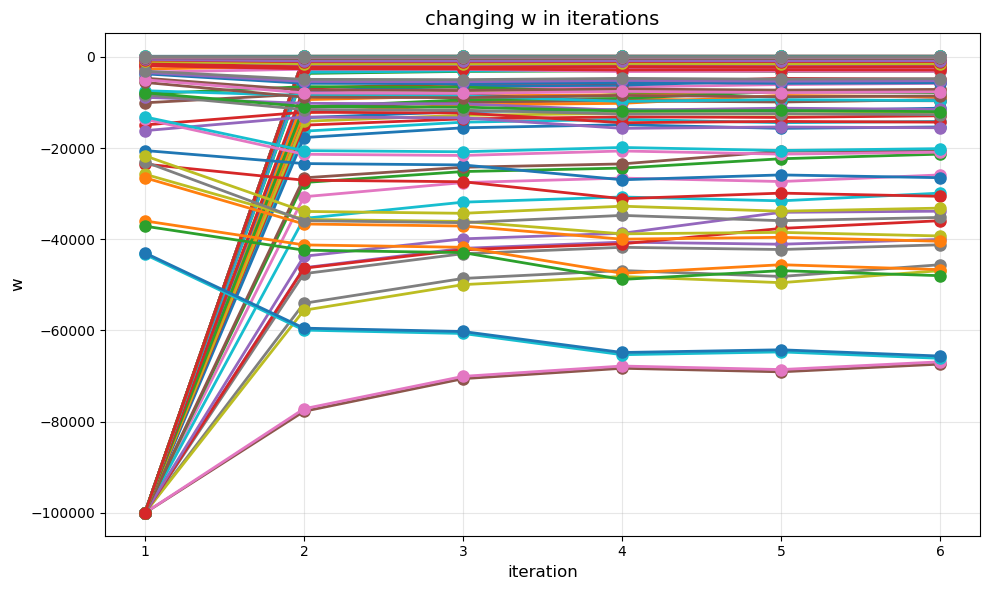

In [7]:
# plot
iterations = list(range(1, len(theta_values[1]) ))  # [1, 2, 3, 4, 5, 6, 7]

# رسم نمودار
plt.figure(figsize=(10, 6))

for scenario, theta_list in theta_values.items():
     plt.plot(iterations, theta_list[1:], marker='o', label=f'سناریو {scenario}', linewidth=2, markersize=8)

for scenario, theta_list in w.items():
     plt.plot(iterations, theta_list[1:], marker='o', label=f'سناریو {scenario}', linewidth=2, markersize=8)

# تنظیمات نمودار
plt.xlabel('iteration', fontsize=12)
plt.ylabel('w', fontsize=12)
plt.title('changing w in iterations', fontsize=14)

plt.grid(True, alpha=0.3)
plt.xticks(iterations)
plt.tight_layout()
plt.show()

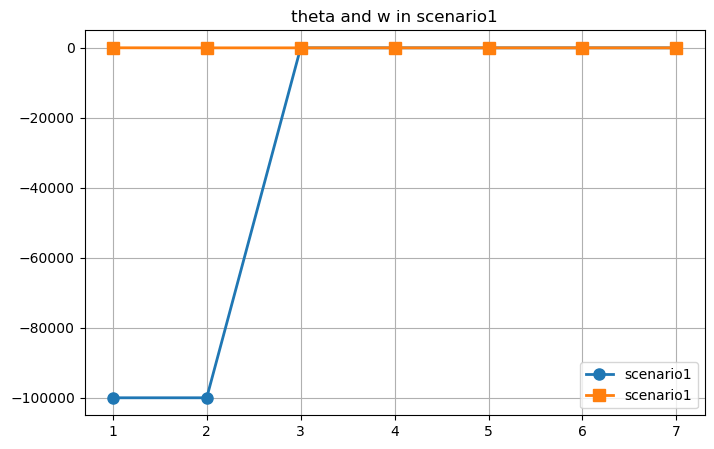

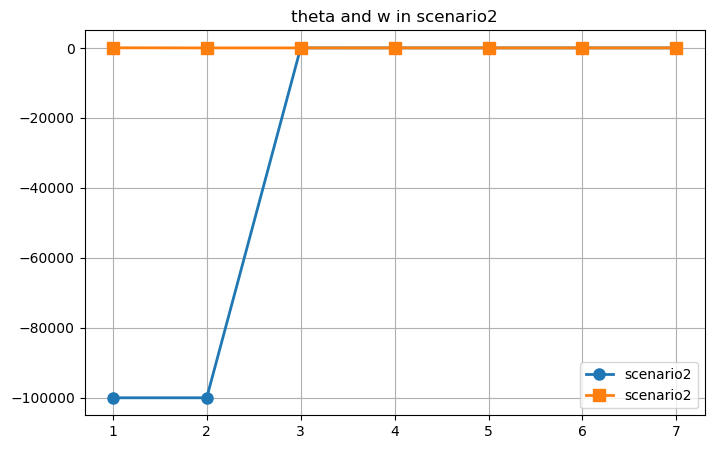

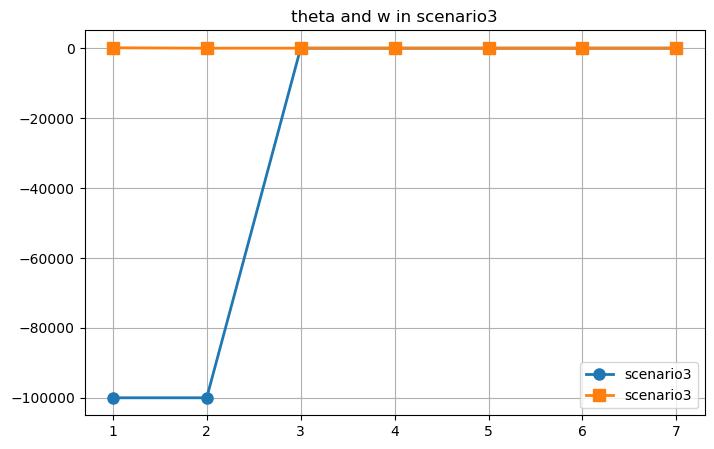

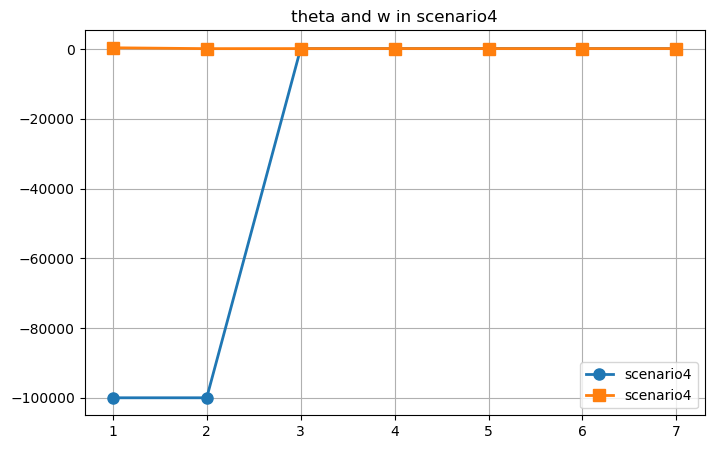

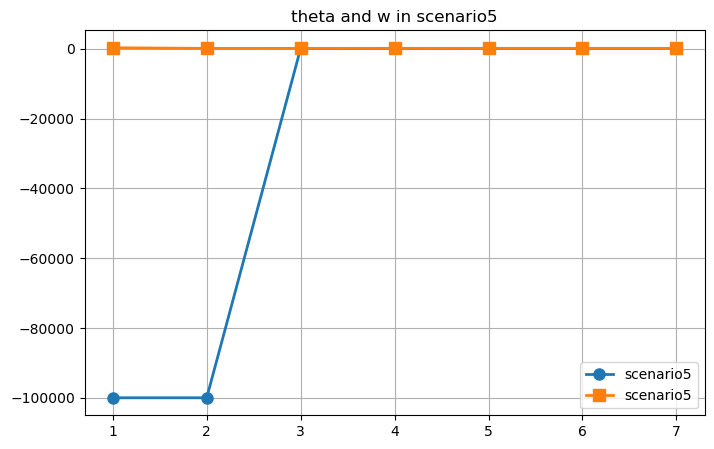

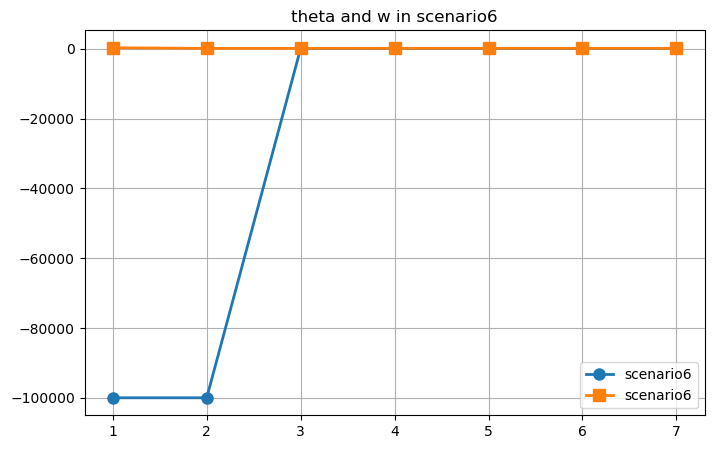

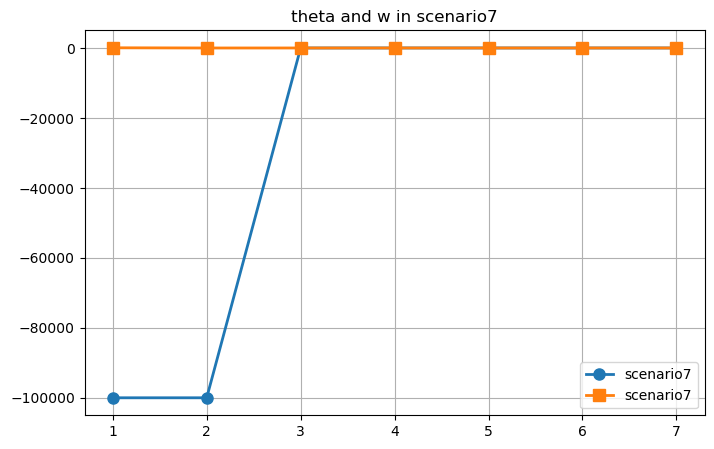

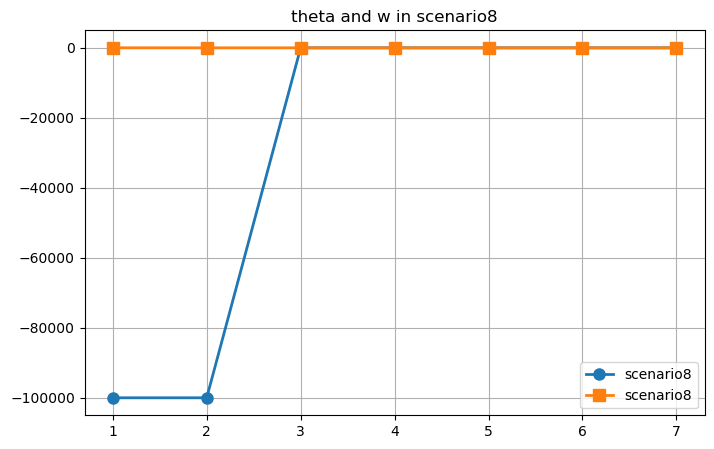

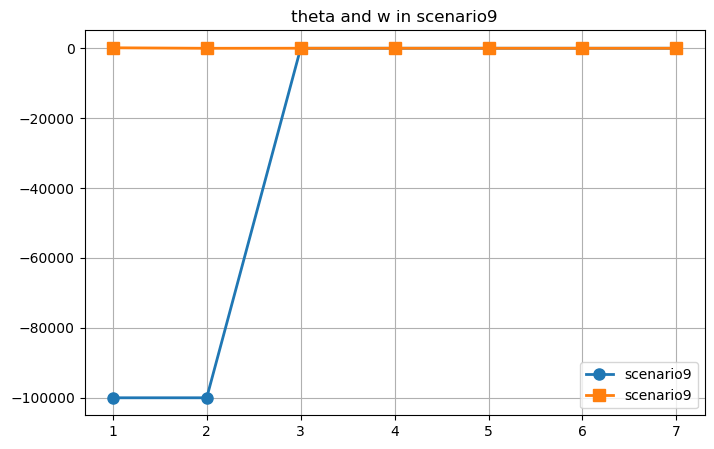

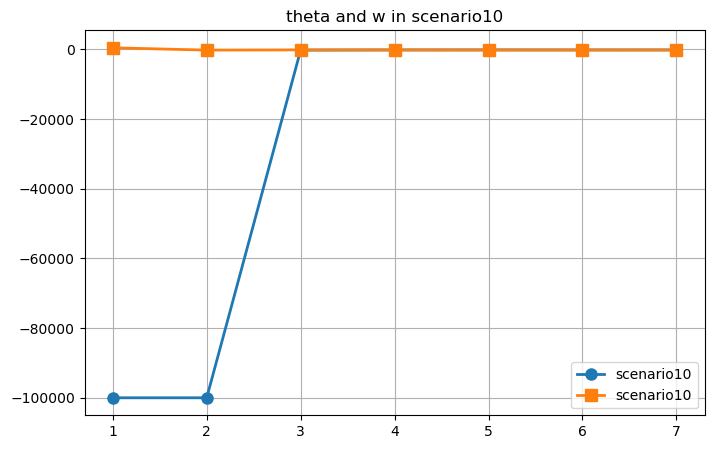

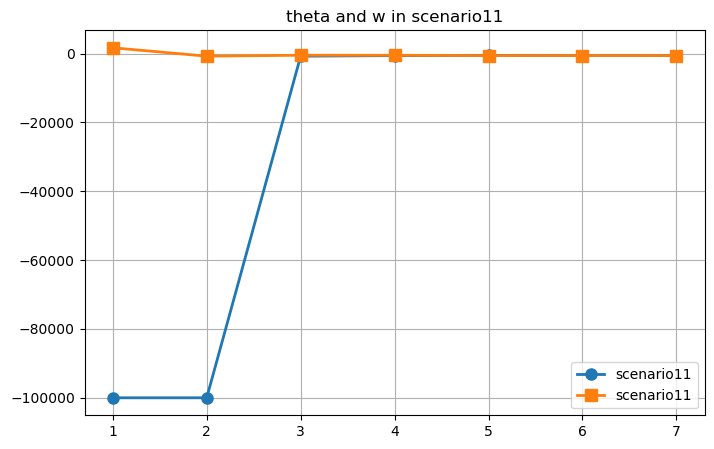

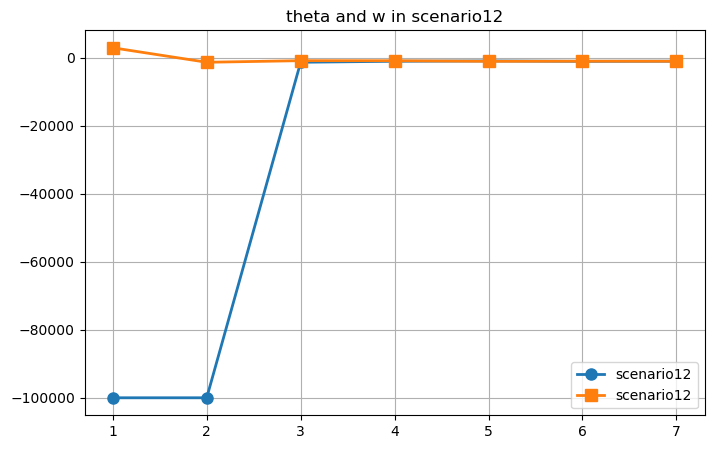

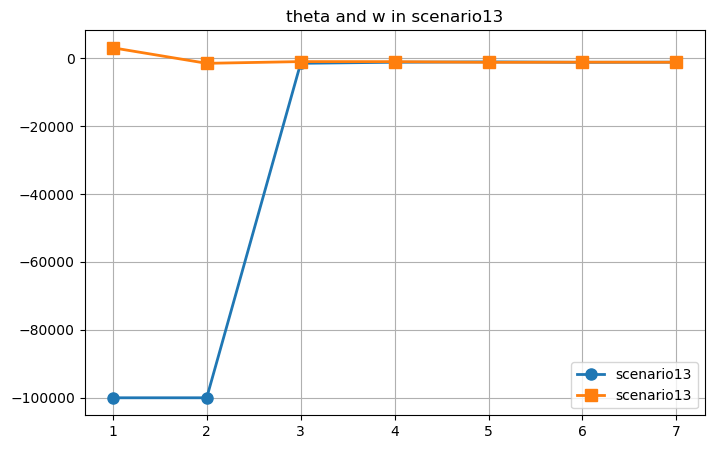

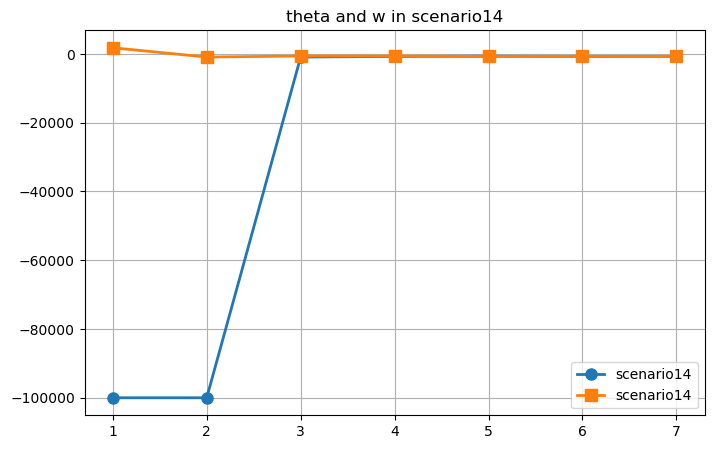

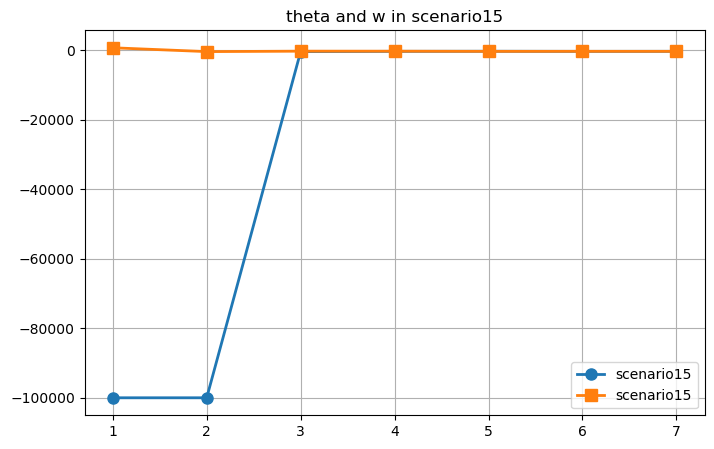

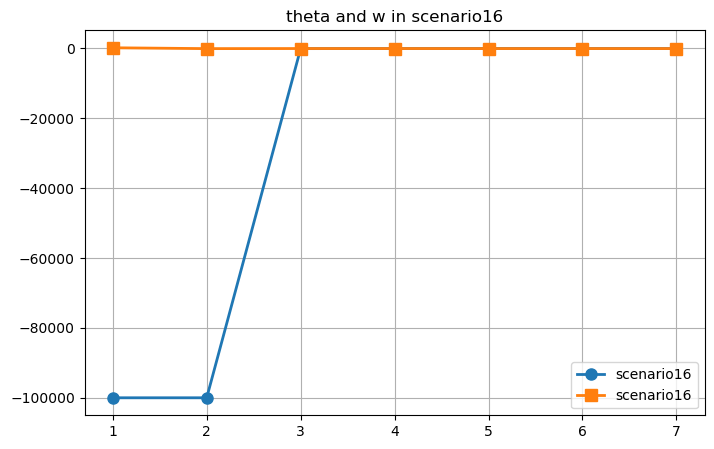

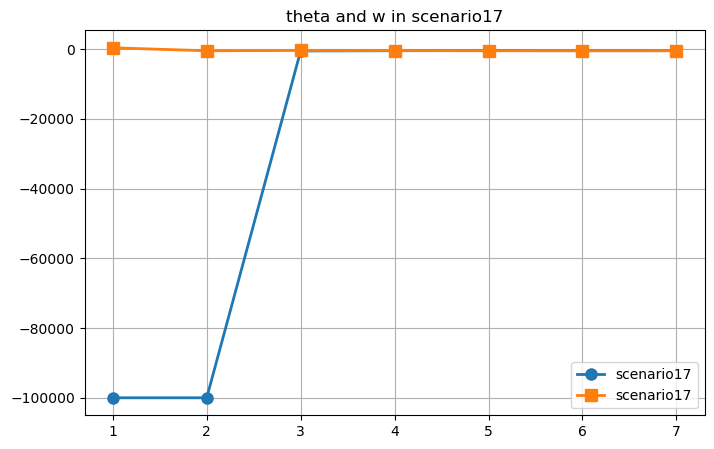

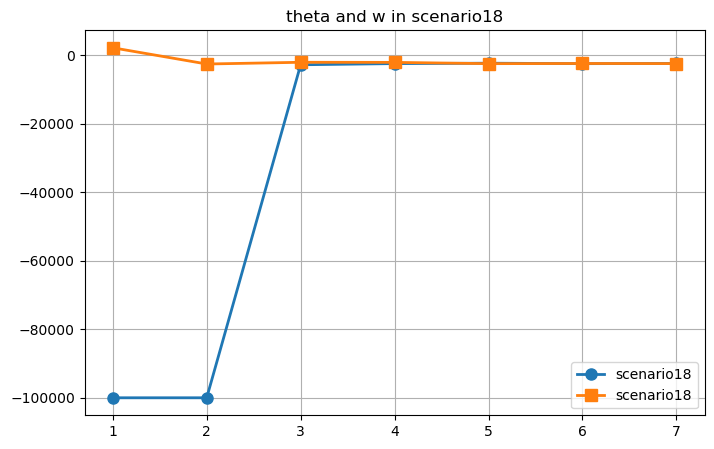

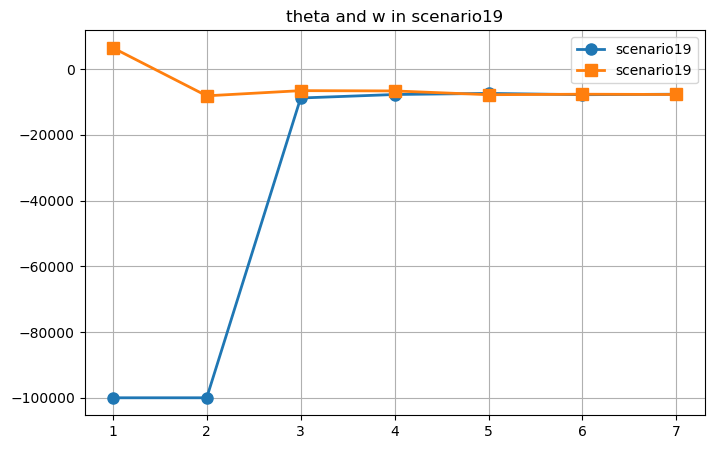

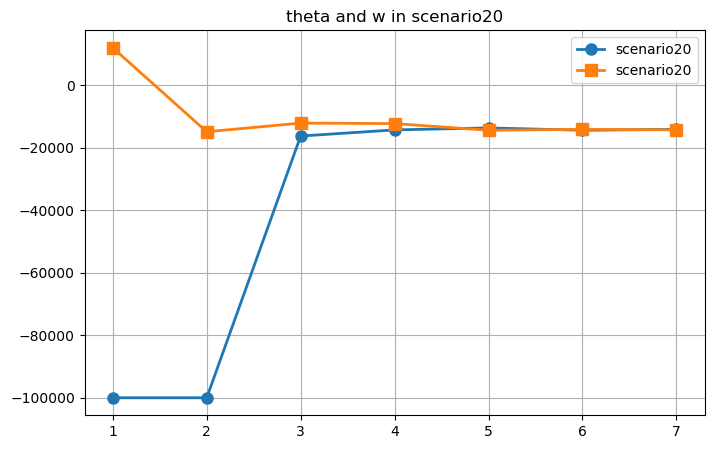

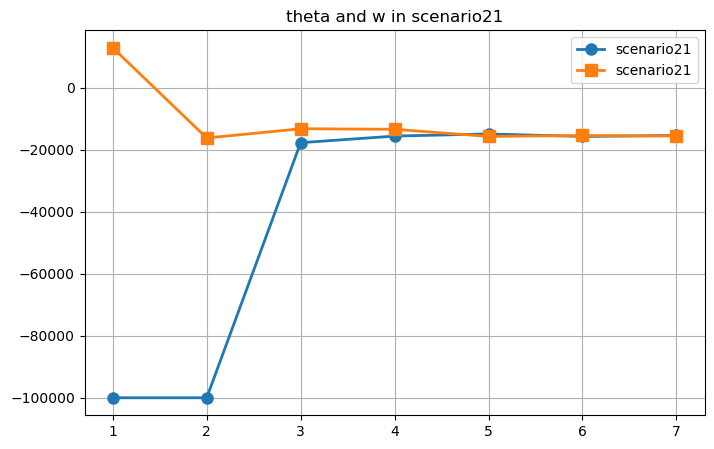

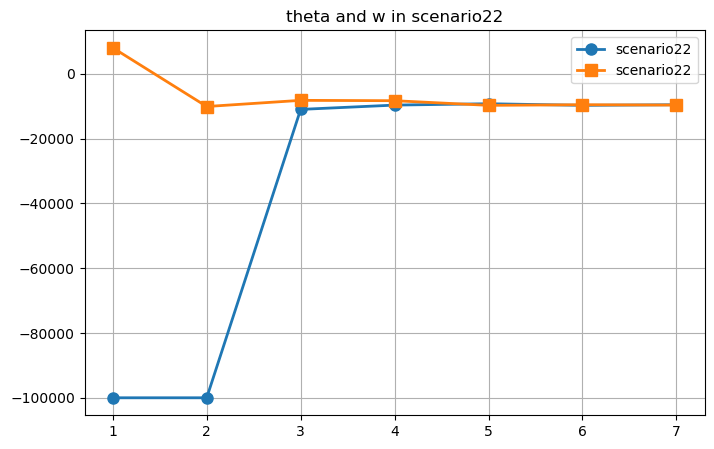

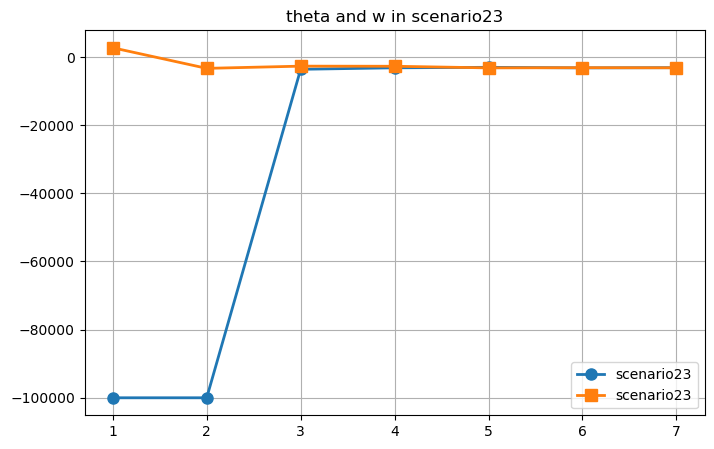

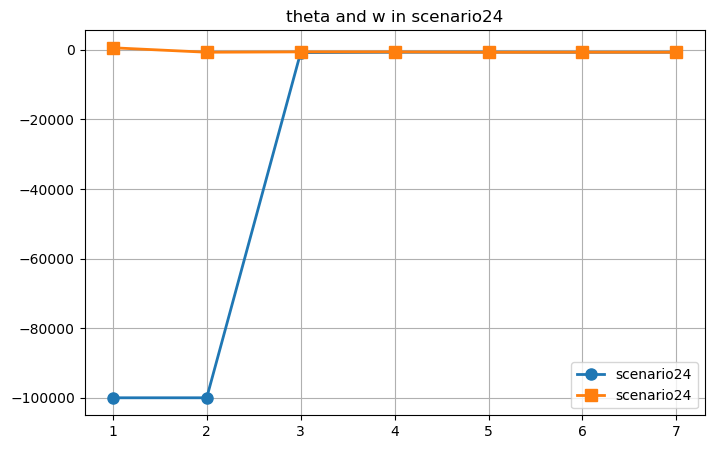

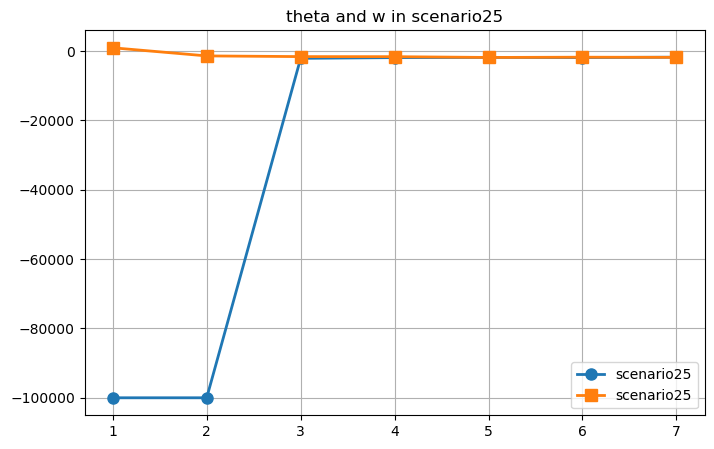

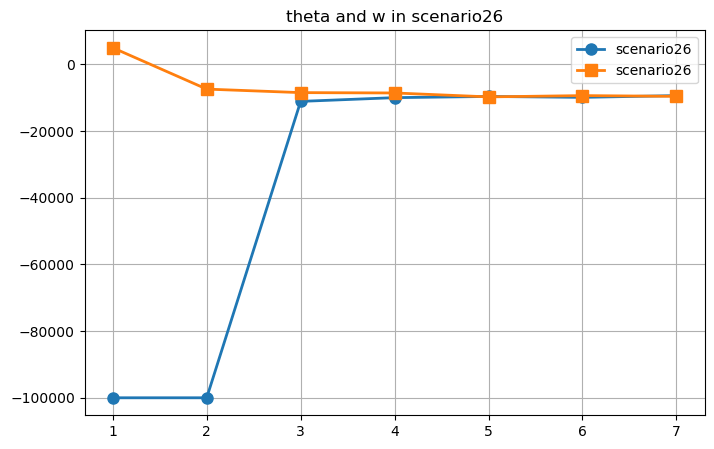

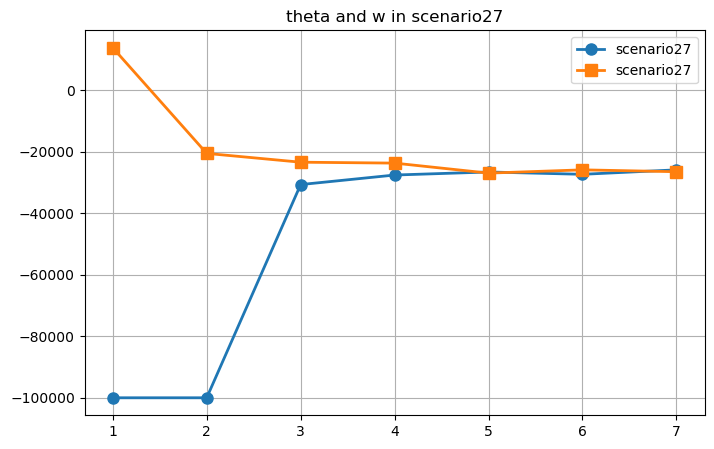

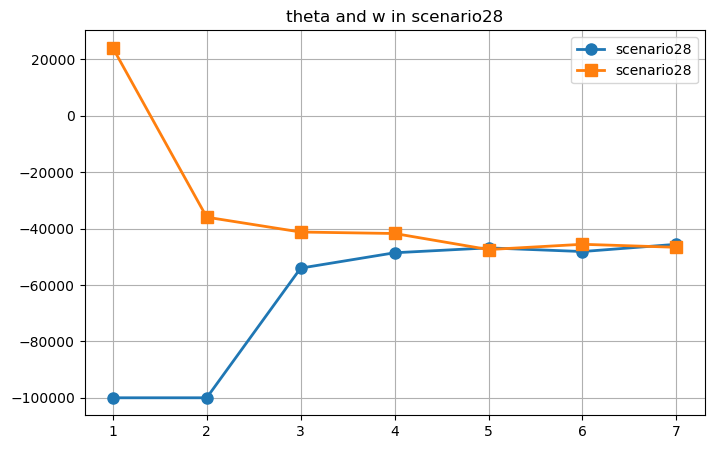

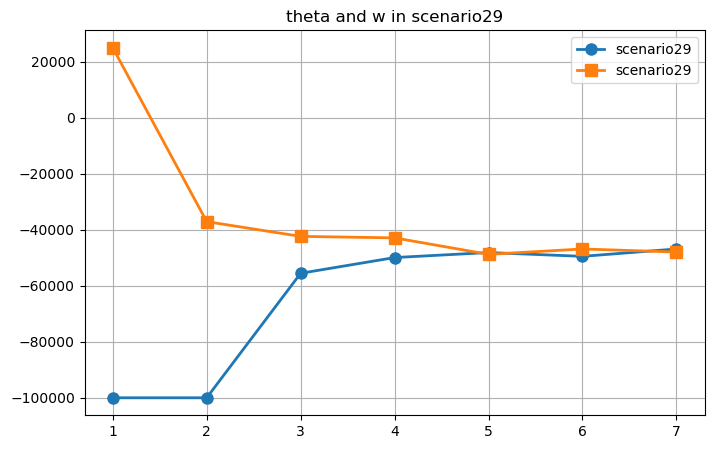

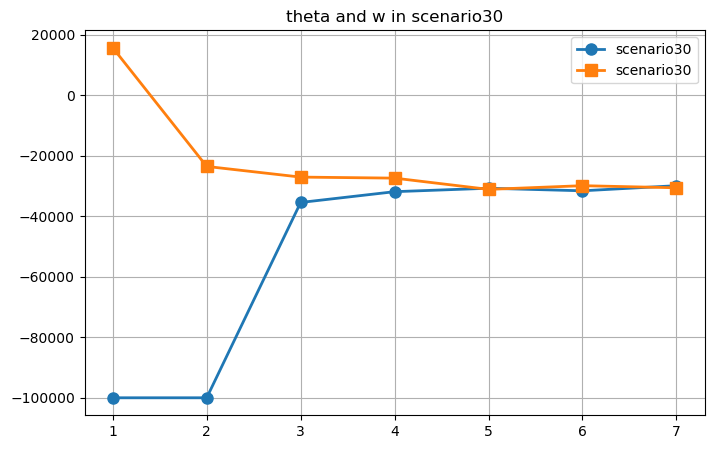

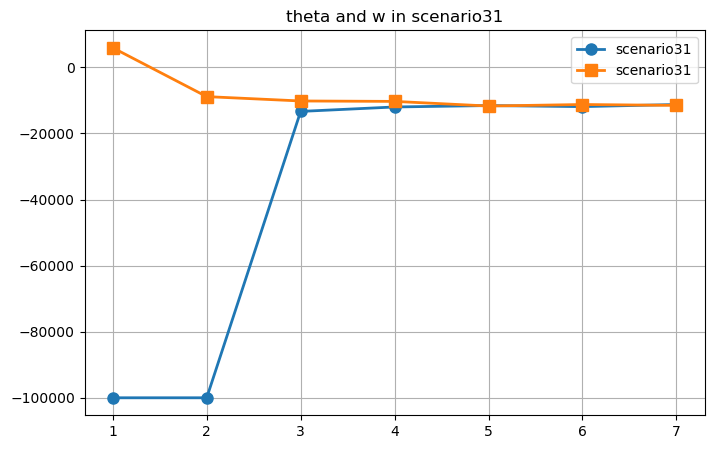

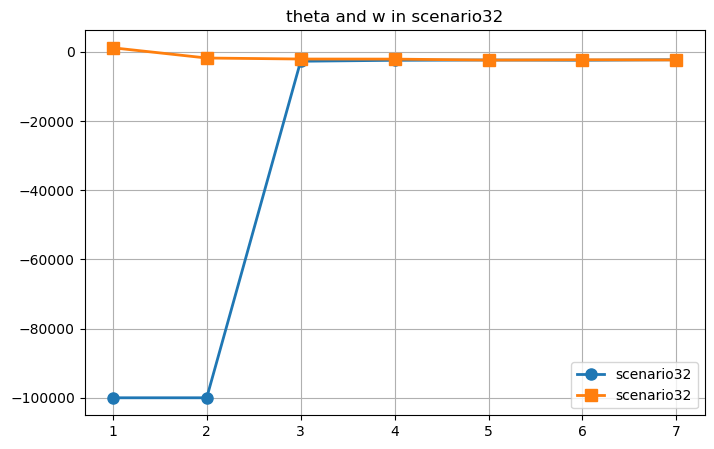

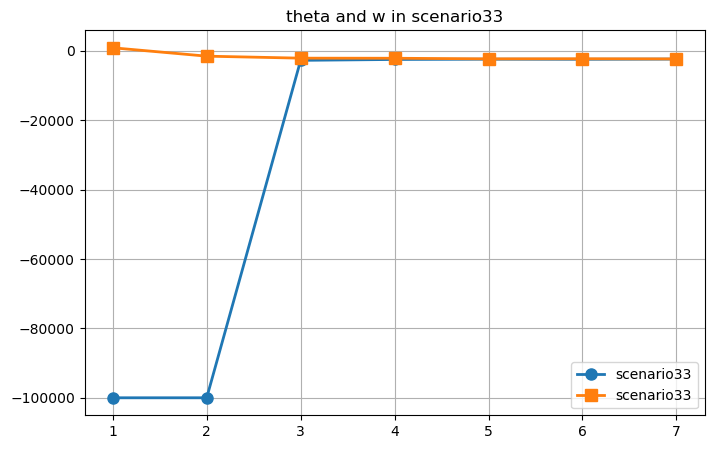

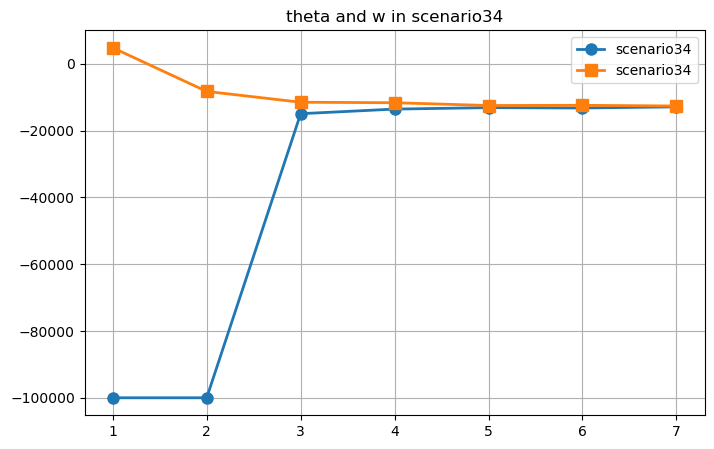

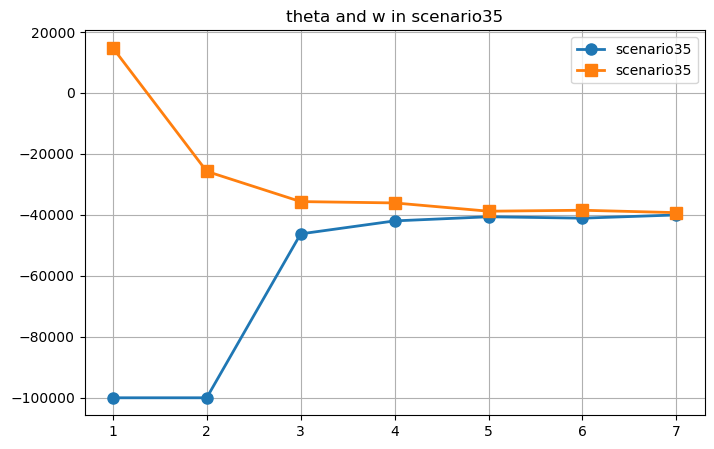

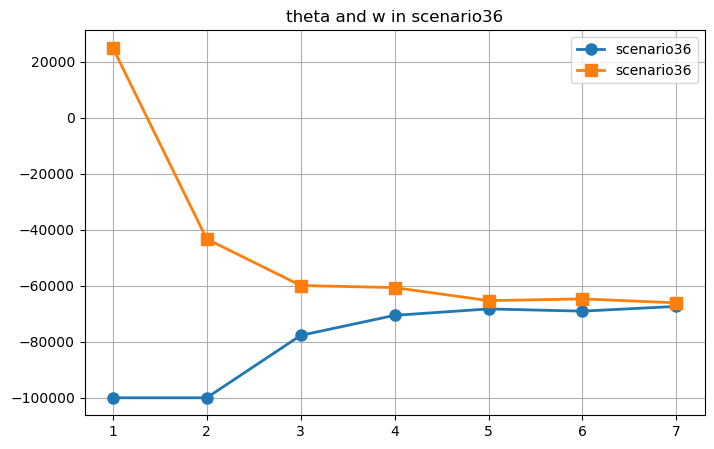

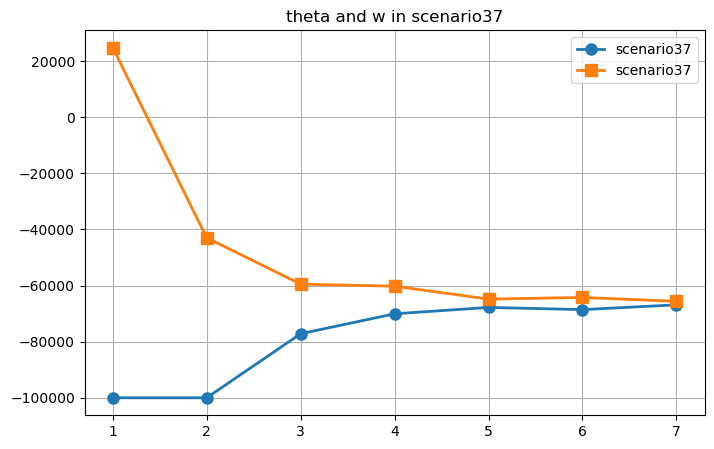

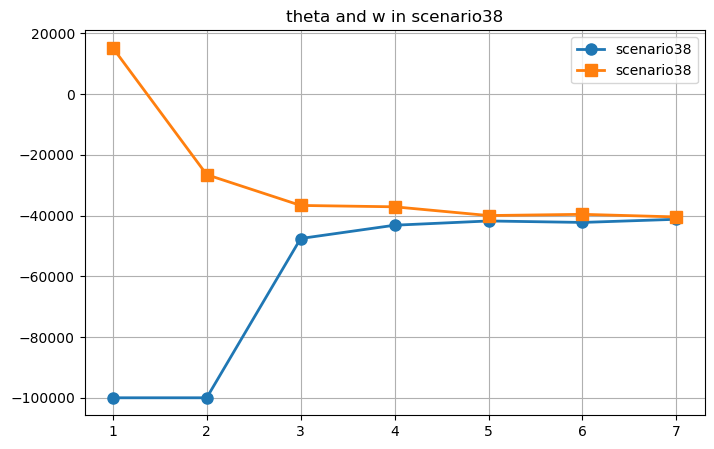

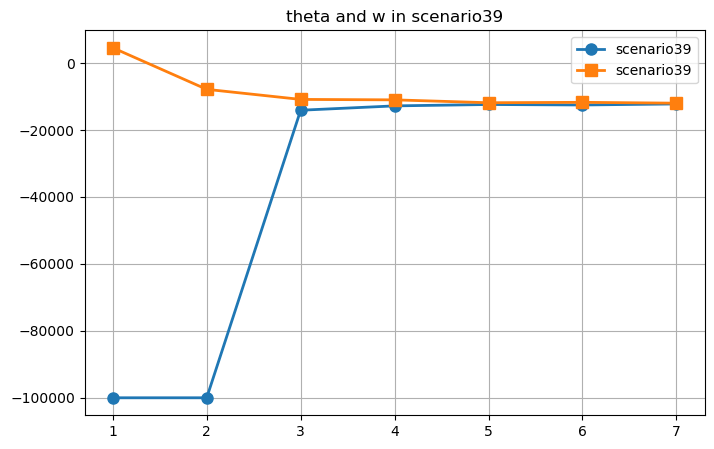

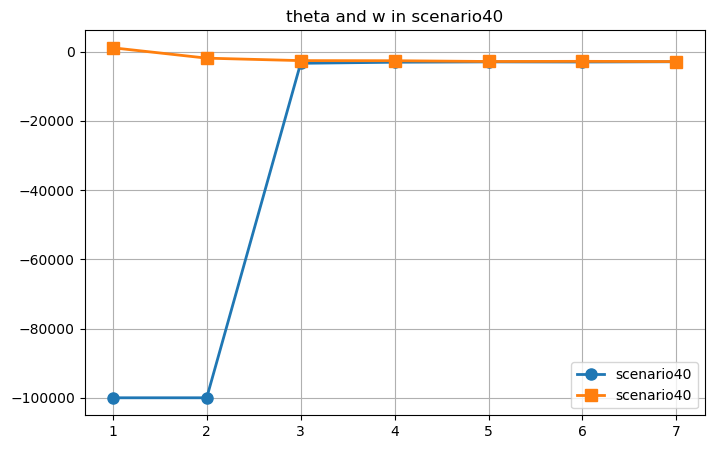

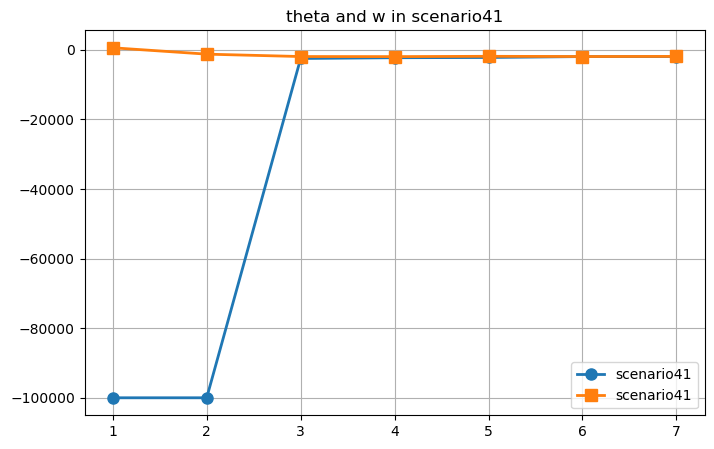

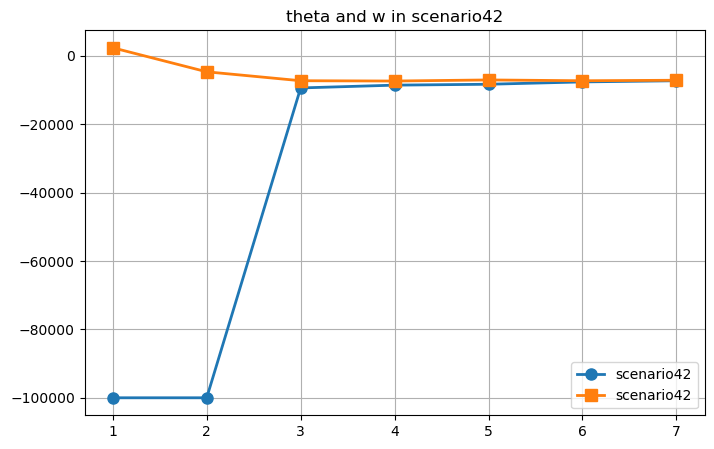

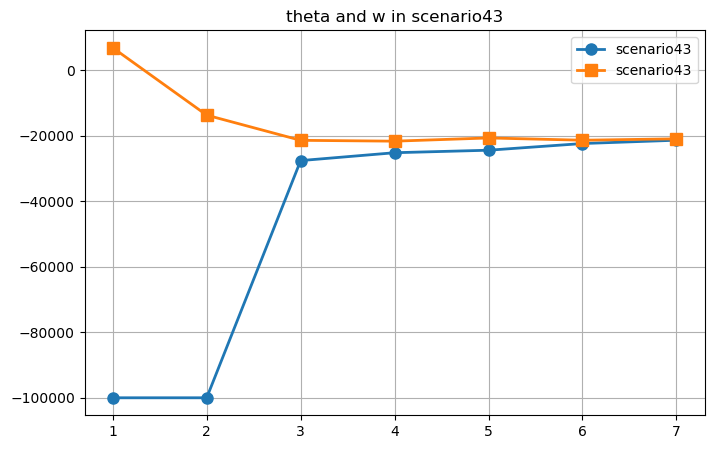

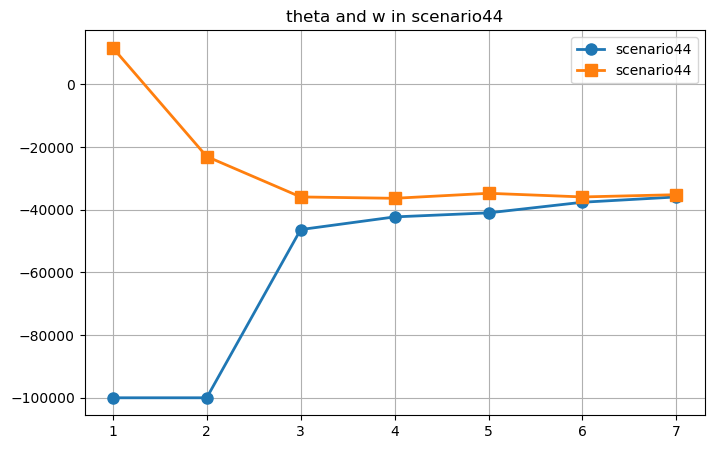

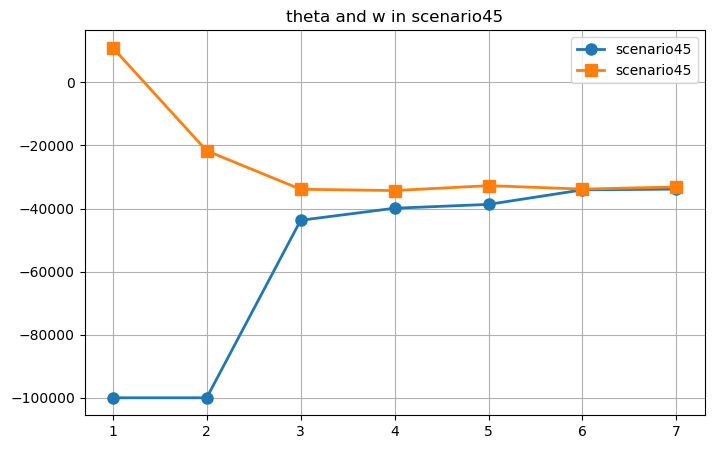

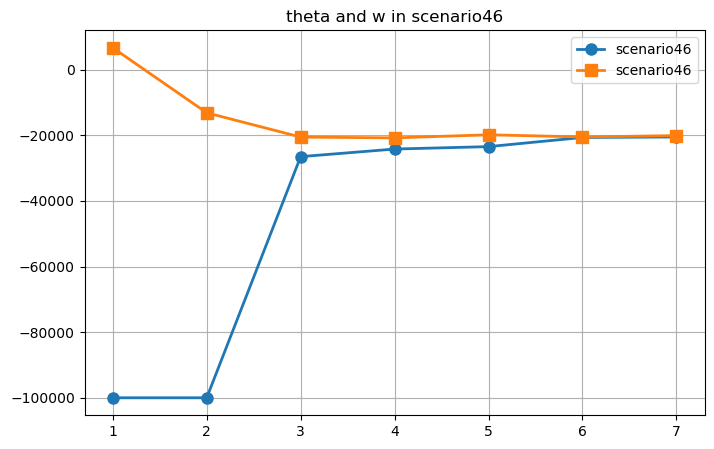

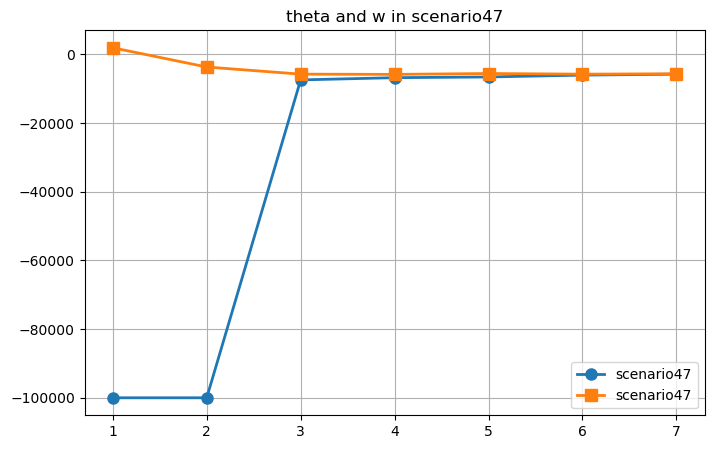

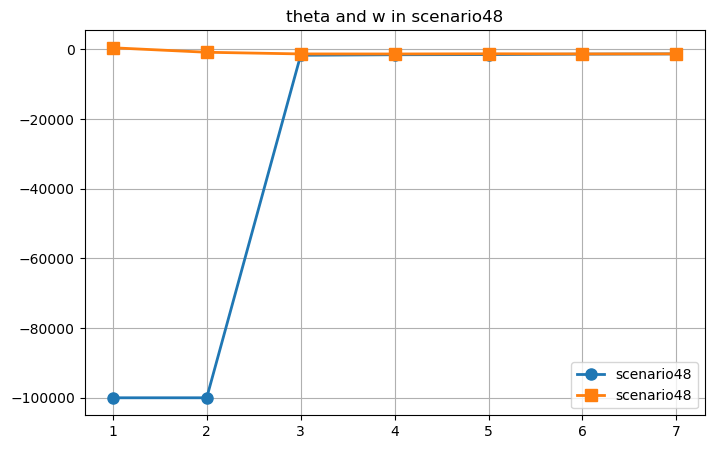

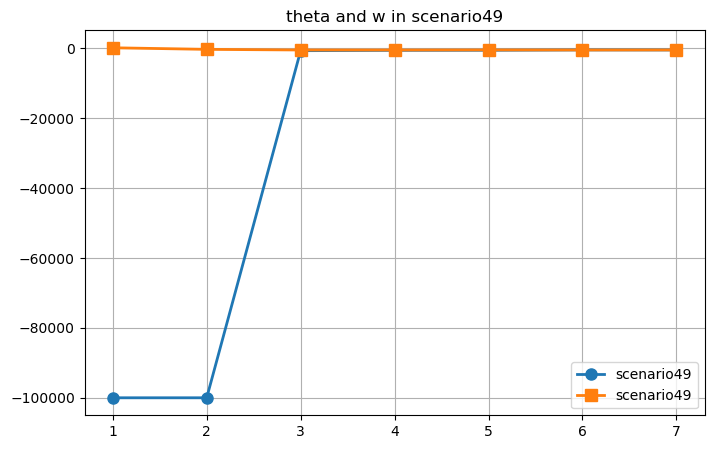

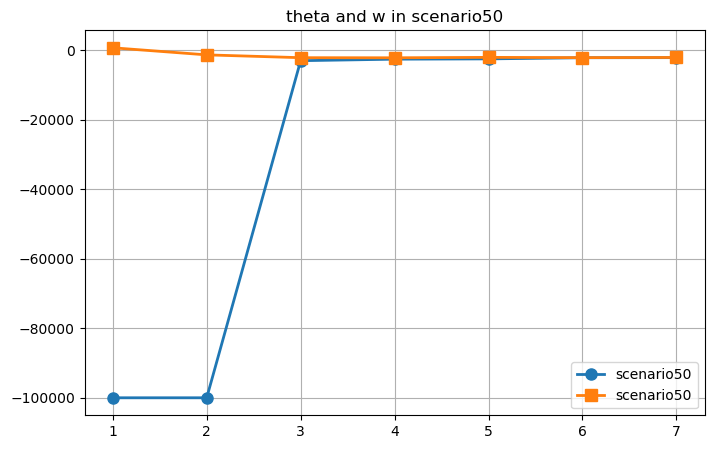

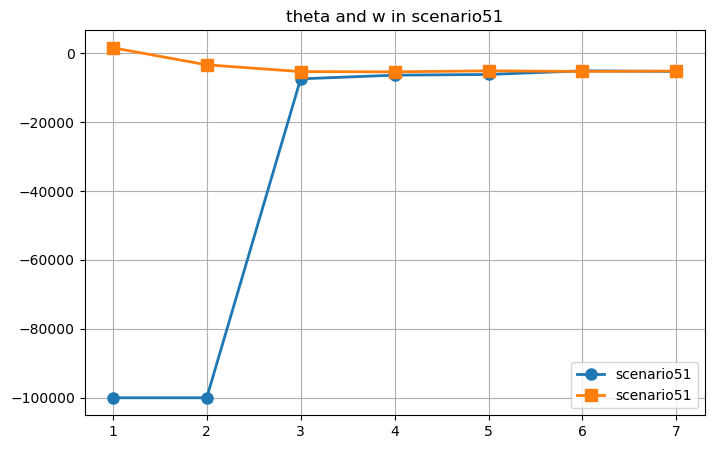

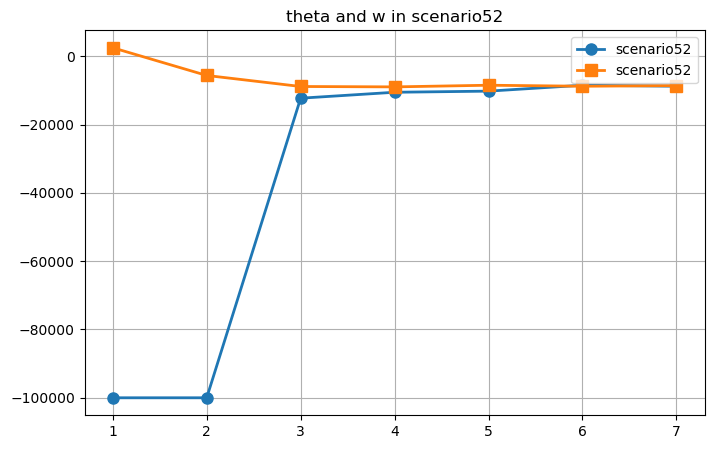

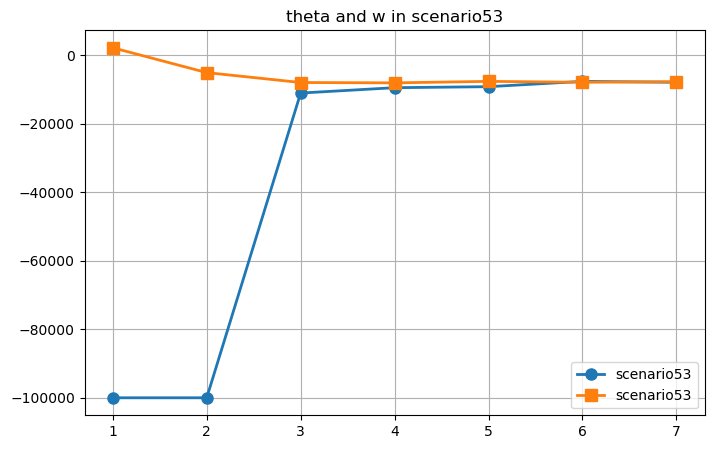

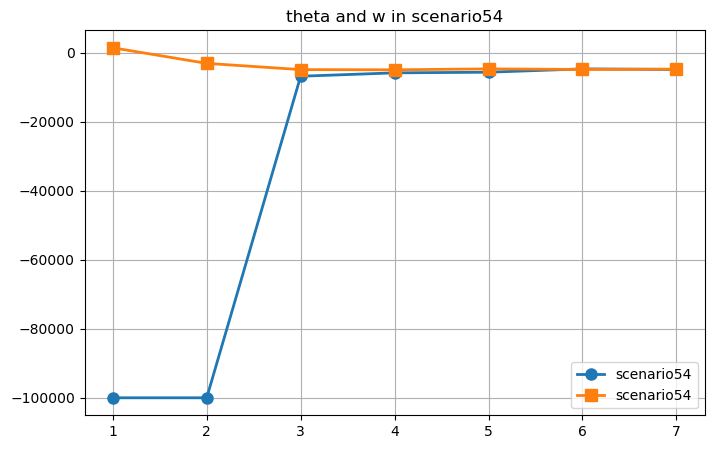

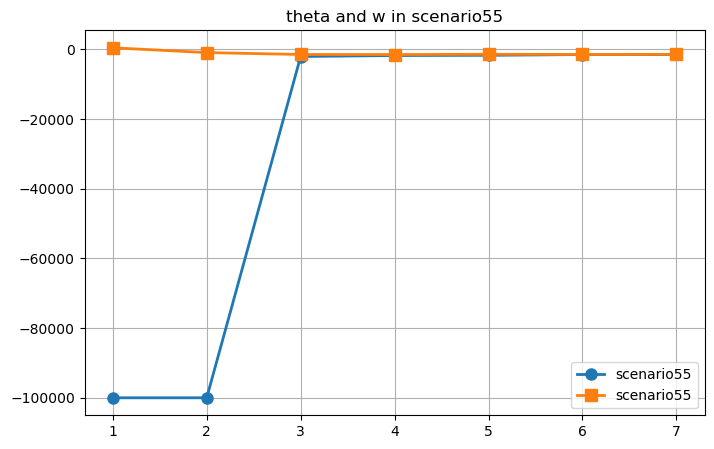

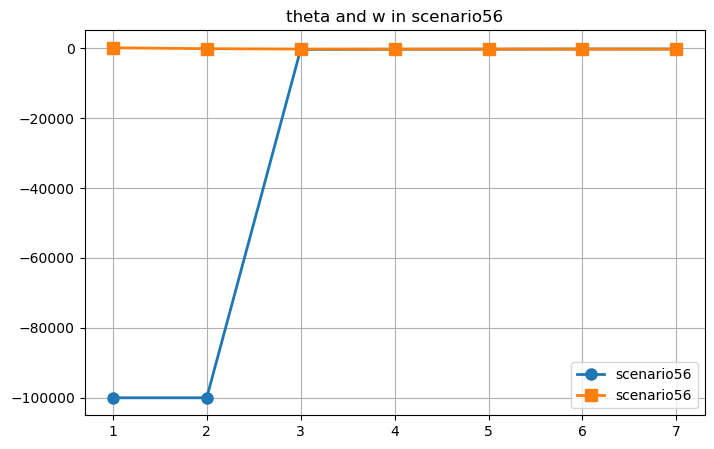

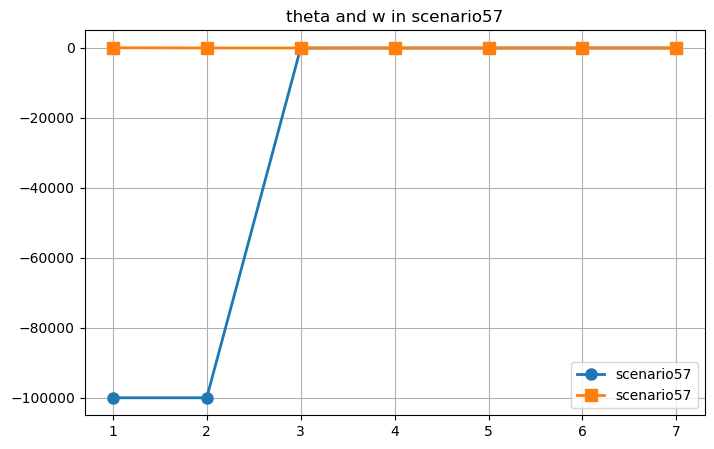

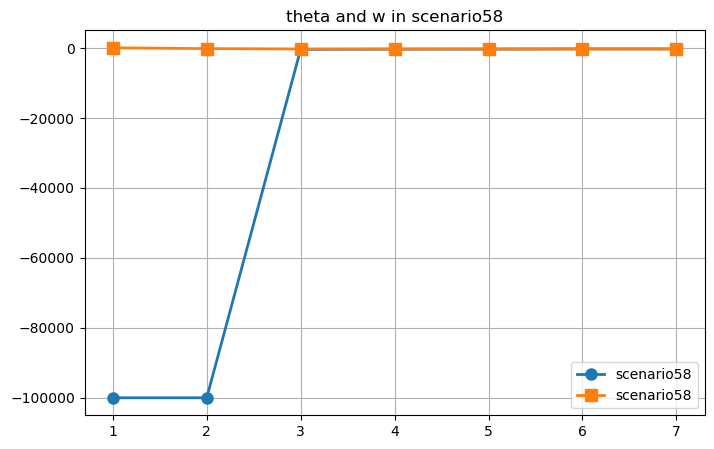

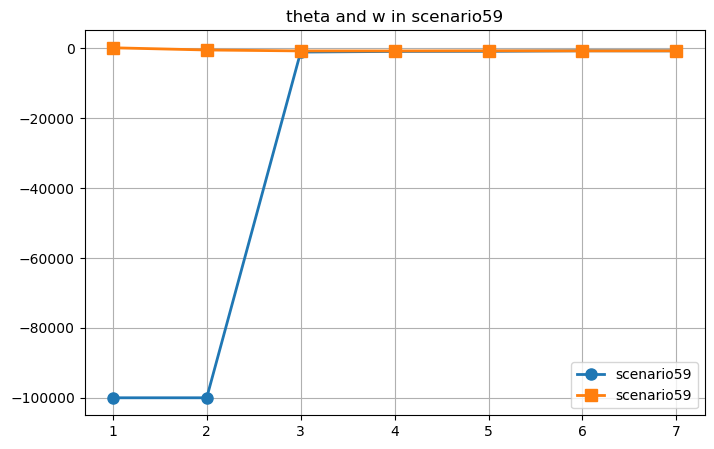

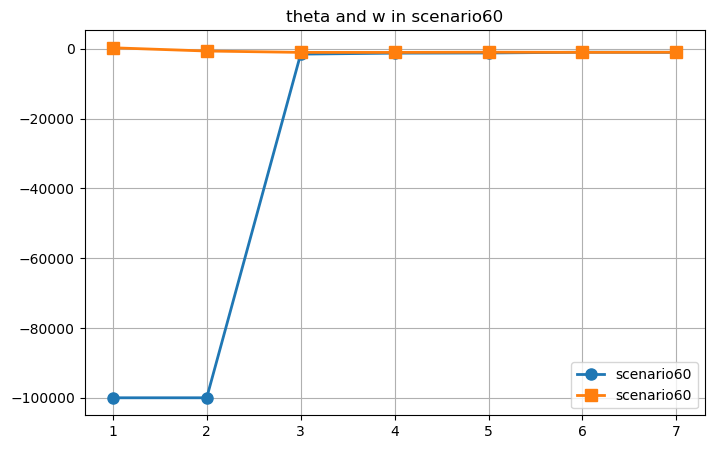

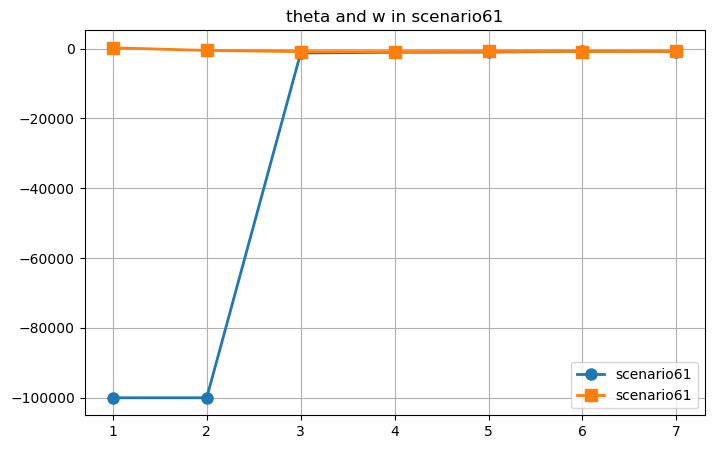

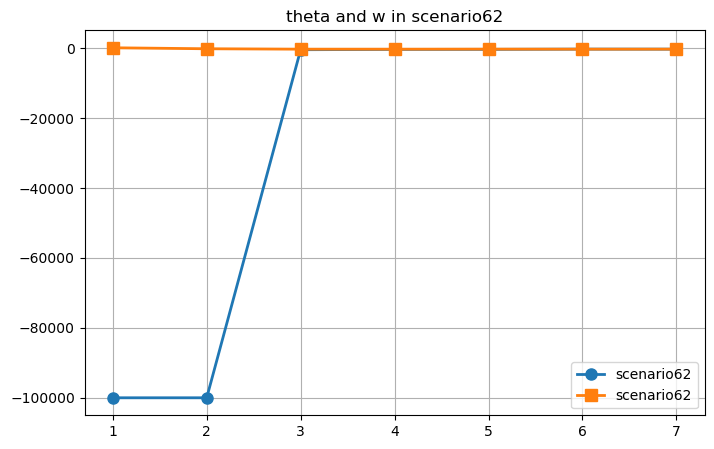

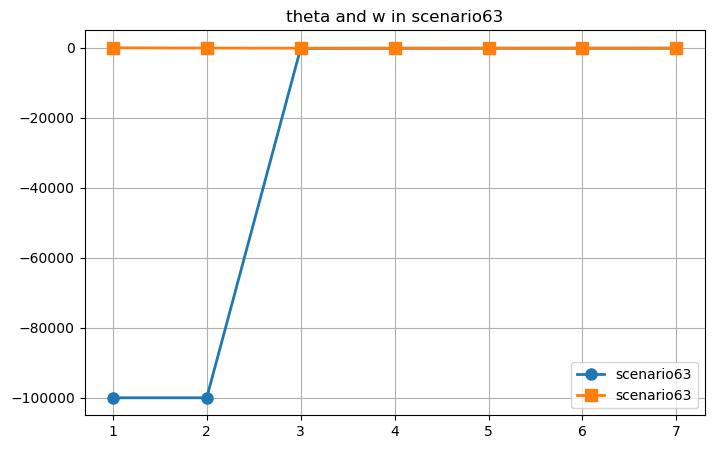

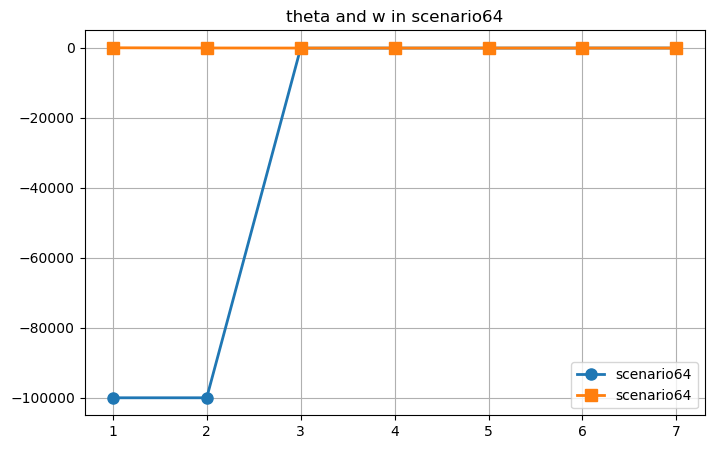

In [8]:
for i in range(1, scenario + 1):
    plt.figure(figsize=(8, 5))  # هر بار یک شکل جدید
    y = theta_values[i]  # فرض می‌کنم ایندکس درسته
    y_2 = w[i]
    plt.plot([1,2,3,4,5,6,7], y, marker='o', label=f'scenario{i}', linewidth=2, markersize=8)
    plt.plot([1,2,3,4,5,6,7], y_2, marker='s', label=f'scenario{i}', linewidth=2, markersize=8)
    plt.legend()
    plt.title(f'theta and w in scenario{i}')
    plt.grid(True)
    plt.show()

f.r.m.n